# Pairs Trading & Statistical Arbitrage
## 03 - Pairs Trading Strategy

This notebook constructs a pairs trading strategy for Visa (V) and Mastercard (MA) using the cointegration relationship established in notebook 02. We extend the analysis by replacing the fixed hedge ratio with a rolling hedge ratio estimated on a trailing window, eliminating the lookahead bias present in notebook 02.

### Rolling Hedge Ratio
In notebook 02 we estimated the hedge ratio using the full sample meaning we used future data to estimate a parameter we would need to know in real time. A rolling hedge ratio fixes this by re-estimating β each day using only the trailing 252 trading days (one year). This ensures every trading decision is made using only information available at that point in time.

### Trading Signals
We construct the spread each day using the rolling hedge ratio and convert it to a z-score. The z-score measures how many standard deviations the spread is from its rolling mean. Our entry and exit rules are:

- **Enter long spread** (long MA, short V) when z-score < -2
- **Enter short spread** (short MA, long V) when z-score > +2
- **Exit position** when z-score reverts to 0

### Why Z-Score Based Entry
Using a z-score rather than raw spread levels makes the signal scale-invariant it adapts automatically as the spread mean and volatility change over time. This is important for a rolling strategy where the reference distribution is constantly being updated.

### Performance
The strategy produced a 3.29% annualized return with 7.74% annualized volatility and a Sharpe ratio of 0.42 over the period 2010 to present. Max drawdown was -12.67% dramatically lower than any strategy in the momentum project.

Raw return comparison to SPY is not the appropriate benchmark for this strategy. Pairs trading is market neutral when long MA and short V simultaneously, broad market exposure is nearly zero. The strategy is taking spread risk, not market risk. The relevant metrics are Sharpe ratio and drawdown, both of which are competitive. In a portfolio context the strategy could be levered to a target volatility while maintaining its low drawdown profile and diversification benefit relative to a long only equity allocation.

### Lookahead Bias Controls
- Rolling hedge ratio uses only trailing 252 days
- Rolling mean and standard deviation for z-score use only trailing 252 days
- All signals are shifted by one day before being applied to returns

In [1]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.regression.linear_model import OLS
from statsmodels.tools import add_constant

# Reload prices
tickers = ["V", "MA"]
raw = yf.download(tickers, start="2010-01-01", auto_adjust=True)["Close"]
prices = raw.dropna()

print(f"Loaded: {prices.shape[0]} days")
print(prices.tail())

[*********************100%***********************]  2 of 2 completed

Loaded: 4159 days
Ticker              MA           V
Date                              
2026-07-13  537.700012  357.750000
2026-07-14  538.020020  356.019989
2026-07-15  535.210022  355.140015
2026-07-16  551.539978  365.140015
2026-07-17  543.599976  358.559998


Rolling hedge ratio (last 5 days):
Date
2026-07-13    1.699674
2026-07-14    1.683905
2026-07-15    1.669222
2026-07-16    1.655852
2026-07-17    1.633885
dtype: float64


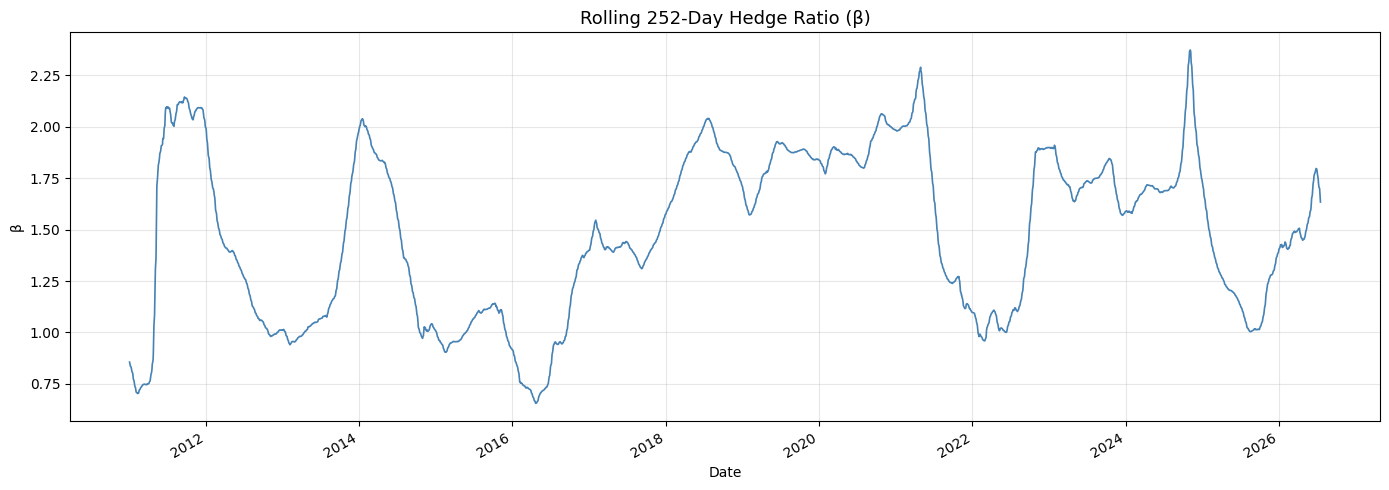

In [2]:
# Rolling 252-day hedge ratio
# Each day we regress MA on V using only the trailing 252 days
window = 252

rolling_beta = pd.Series(index=prices.index, dtype=float)
rolling_alpha = pd.Series(index=prices.index, dtype=float)

for i in range(window, len(prices)):
    window_prices = prices.iloc[i-window:i]
    X = add_constant(window_prices["V"])
    y = window_prices["MA"]
    model = OLS(y, X).fit()
    rolling_beta.iloc[i] = model.params["V"]
    rolling_alpha.iloc[i] = model.params["const"]

print("Rolling hedge ratio (last 5 days):")
print(rolling_beta.tail())

# Plot rolling hedge ratio
fig, ax = plt.subplots(figsize=(14, 5))
rolling_beta.plot(ax=ax, color="steelblue", linewidth=1.2)
ax.set_title("Rolling 252-Day Hedge Ratio (β)", fontsize=13)
ax.set_ylabel("β")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

Z-score (last 5 days):
Date
2026-07-13   -1.894474
2026-07-14   -1.707071
2026-07-15   -1.729784
2026-07-16   -1.704599
2026-07-17   -1.527462
dtype: float64


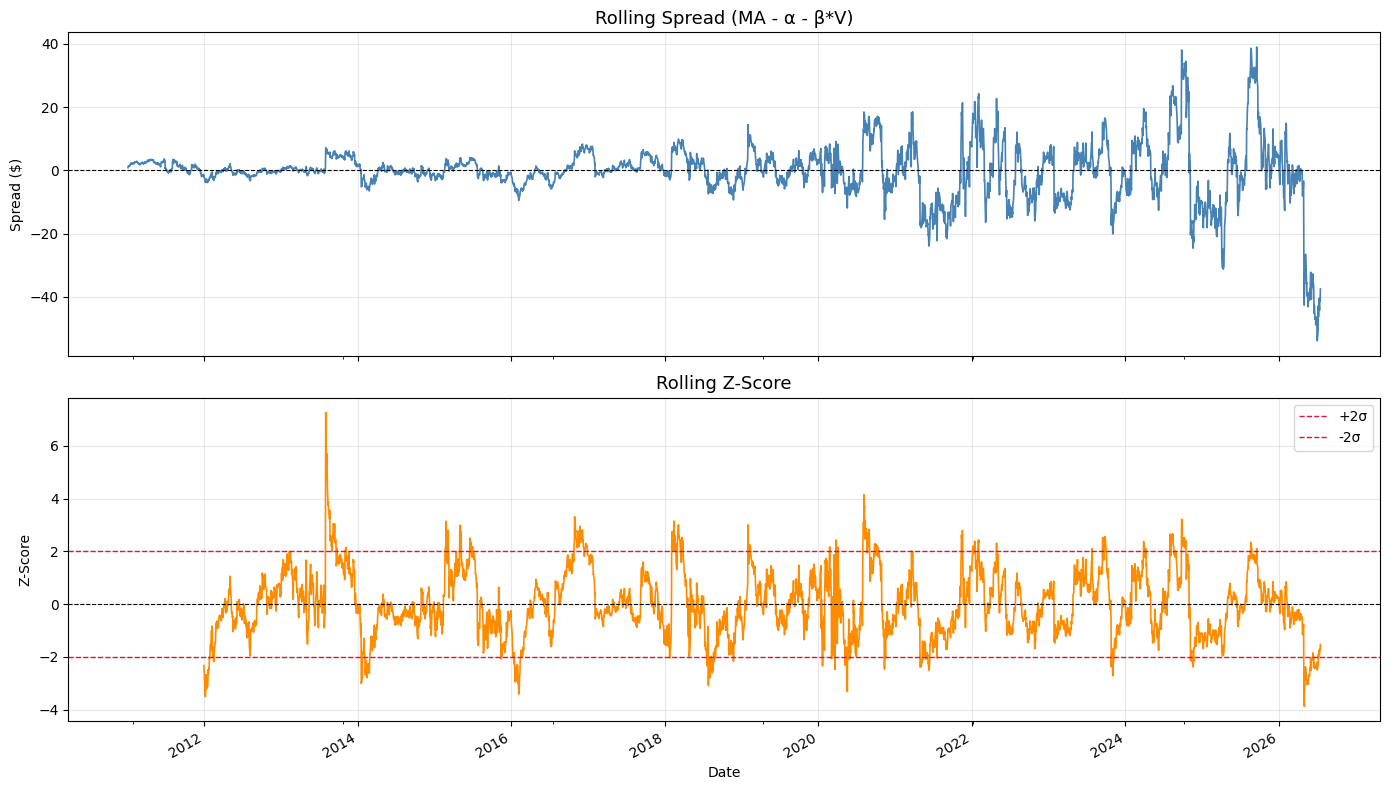

In [3]:
# Spread using rolling hedge ratio
spread = prices["MA"] - (rolling_alpha + rolling_beta * prices["V"])

# Rolling z-score using 252-day trailing mean and std
rolling_mean = spread.rolling(window=252).mean()
rolling_std = spread.rolling(window=252).std()
zscore = (spread - rolling_mean) / rolling_std

print("Z-score (last 5 days):")
print(zscore.tail())

# Plot spread and z-score
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

spread.plot(ax=ax1, color="steelblue", linewidth=1.2)
ax1.axhline(0, color="black", linewidth=0.8, linestyle="--")
ax1.set_title("Rolling Spread (MA - α - β*V)", fontsize=13)
ax1.set_ylabel("Spread ($)")
ax1.grid(alpha=0.3)

zscore.plot(ax=ax2, color="darkorange", linewidth=1.2)
ax2.axhline(0, color="black", linewidth=0.8, linestyle="--")
ax2.axhline(2, color="crimson", linewidth=1, linestyle="--", label="+2σ")
ax2.axhline(-2, color="crimson", linewidth=1, linestyle="--", label="-2σ")
ax2.set_title("Rolling Z-Score", fontsize=13)
ax2.set_ylabel("Z-Score")
ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()


In [4]:
# Signal generation
# 1 = long spread (long MA, short V)
# -1 = short spread (short MA, long V)
# 0 = no position

signals = pd.Series(0, index=zscore.index)
position = 0

for i in range(len(zscore)):
    z = zscore.iloc[i]
    
    if np.isnan(z):
        signals.iloc[i] = 0
        continue
    
    if position == 0:
        if z < -2:
            position = 1   # enter long spread
        elif z > 2:
            position = -1  # enter short spread
    
    elif position == 1:
        if z >= 0:
            position = 0   # exit long spread
    
    elif position == -1:
        if z <= 0:
            position = 0   # exit short spread
    
    signals.iloc[i] = position

print("Signal counts:")
print(signals.value_counts())
print(f"\nSample signals (last 10 days):")
print(signals.tail(10))


Signal counts:
 0    2724
 1     764
-1     671
Name: count, dtype: int64

Sample signals (last 10 days):
Date
2026-07-06    1
2026-07-07    1
2026-07-08    1
2026-07-09    1
2026-07-10    1
2026-07-13    1
2026-07-14    1
2026-07-15    1
2026-07-16    1
2026-07-17    1
dtype: int64


In [5]:
# Daily log returns for each stock
log_returns = np.log(prices / prices.shift(1))

# Strategy return each day
# Long spread = long MA, short V
# Short spread = short MA, long V
# We shift signals by 1 to avoid lookahead bias
strategy_returns = (
    signals.shift(1) * log_returns["MA"] -
    signals.shift(1) * log_returns["V"]
)

strategy_returns = strategy_returns.dropna()

# Performance metrics
ann_return = strategy_returns.mean() * 252
ann_vol = strategy_returns.std() * np.sqrt(252)
sharpe = ann_return / ann_vol
cumulative = strategy_returns.cumsum()
drawdown = cumulative - cumulative.cummax()
max_dd = drawdown.min()

print("=" * 40)
print("STRATEGY PERFORMANCE")
print("=" * 40)
print(f"Annualized Return:  {ann_return:.2%}")
print(f"Annualized Vol:     {ann_vol:.2%}")
print(f"Sharpe Ratio:       {sharpe:.2f}")
print(f"Max Drawdown:       {max_dd:.2%}")
print(f"Period:             {strategy_returns.index[0].date()} to {strategy_returns.index[-1].date()}")

STRATEGY PERFORMANCE
Annualized Return:  3.29%
Annualized Vol:     7.74%
Sharpe Ratio:       0.42
Max Drawdown:       -12.67%
Period:             2010-01-05 to 2026-07-17


[*********************100%***********************]  1 of 1 completed


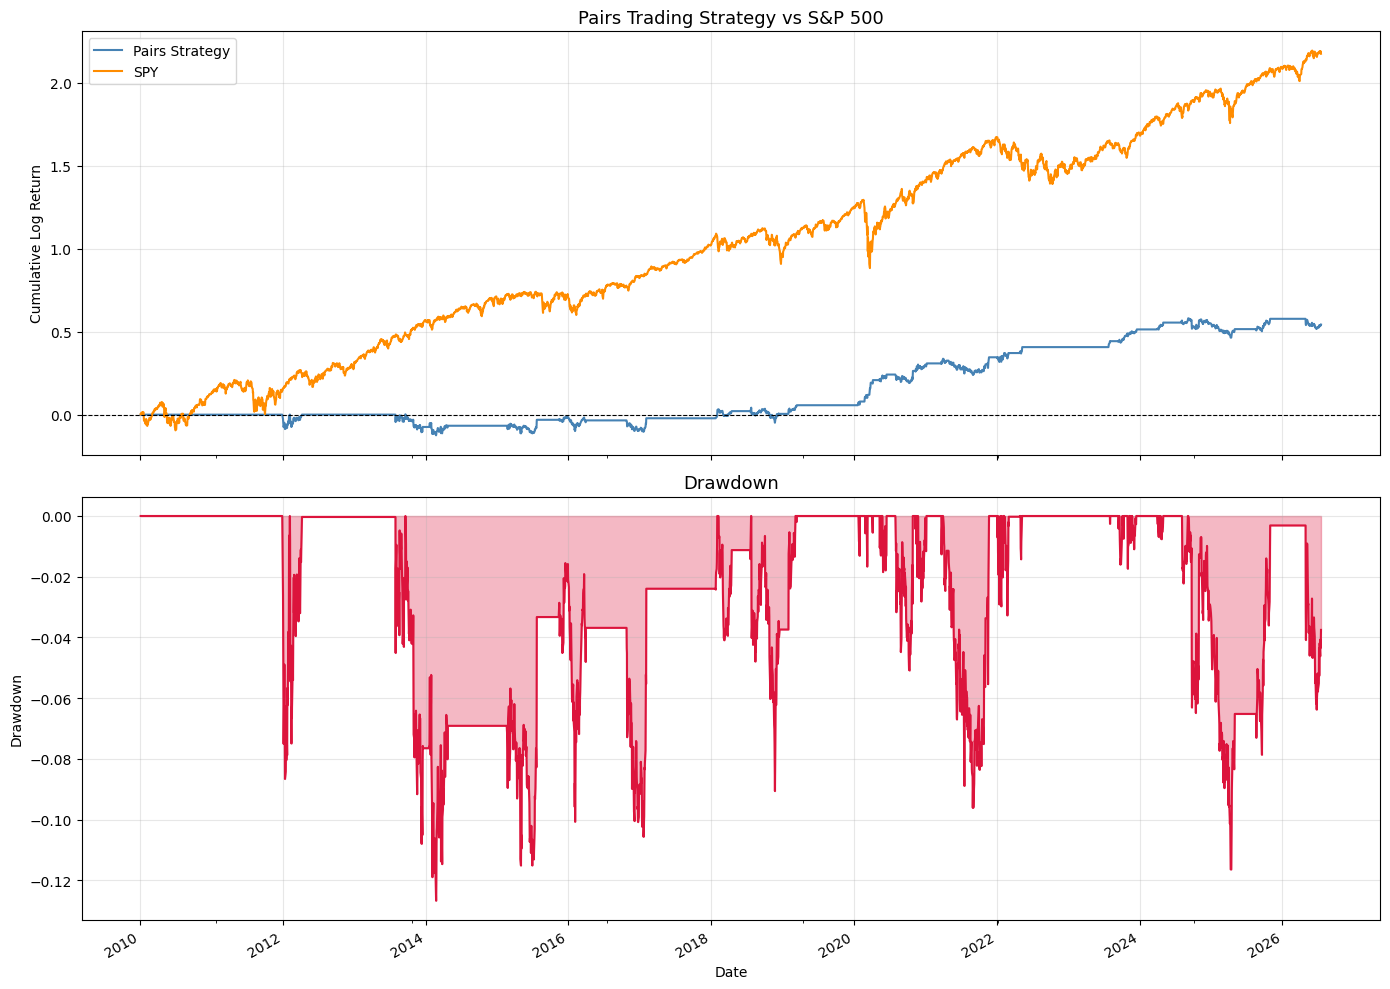

In [6]:
# Pull SPY for comparison
spy = yf.download("SPY", start="2010-01-01", auto_adjust=True)["Close"]
spy_returns = np.log(spy / spy.shift(1)).dropna()
spy_returns = spy_returns.reindex(strategy_returns.index)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10), sharex=True)

# Cumulative returns
strategy_returns.cumsum().plot(ax=ax1, color="steelblue", linewidth=1.5, label="Pairs Strategy")
spy_returns.cumsum().plot(ax=ax1, color="darkorange", linewidth=1.5, label="S&P 500 (SPY)")
ax1.axhline(0, color="black", linewidth=0.8, linestyle="--")
ax1.set_title("Pairs Trading Strategy vs S&P 500", fontsize=13)
ax1.set_ylabel("Cumulative Log Return")
ax1.legend()
ax1.grid(alpha=0.3)

# Drawdown
drawdown.plot(ax=ax2, color="crimson", linewidth=1.5)
ax2.fill_between(drawdown.index, drawdown, 0, alpha=0.3, color="crimson")
ax2.set_title("Drawdown", fontsize=13)
ax2.set_ylabel("Drawdown")
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()